# Notebook 04: EDA Sustancias Legales (Tabaco y Alcohol)

**Objetivos de este notebook:**
1. Calcular los indicadores epidemiológicos estándar (Prevalencia de Vida, Prevalencia de Año, Prevalencia de Mes) para tabaco y alcohol, utilizando el factor de expansión.
2. Analizar la edad de inicio de consumo de ambas sustancias y ver su distribución.
3. Evaluar el consumo de cigarrillos electrónicos (vapeadores).
4. Analizar patrones de consumo problemático de alcohol (frecuencia de embriaguez).

**Nota metodológica sobre edades:** En la encuesta, las personas que no responden o no saben a qué edad iniciaron el consumo suelen ser codificadas con `98` o `99`. Es **vital** convertir estos valores a nulos (`NaN`) antes de calcular promedios, de lo contrario distorsionaremos las estadísticas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
BASE_DIR = Path('..')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cargar el DataFrame Maestro
df = pd.read_parquet(PROCESSED_DIR / 'df_master.parquet')

# Asegurar que fex_c sea numérico
df['fex_c'] = pd.to_numeric(df['fex_c'], errors='coerce').fillna(0)

# Función de cálculo ponderado (reutilizada)
def calcular_tasa_prevalencia(df, col_filtro, valor_positivo=1):
    """
    Calcula la tasa de prevalencia de una variable binaria en la población total.
    Retorna el % de personas que cumplen la condición.
    """
    pob_total = df['fex_c'].sum()
    pob_positiva = df[df[col_filtro] == valor_positivo]['fex_c'].sum()
    return (pob_positiva / pob_total) * 100

print(f"Base cargada. Población representada: {df['fex_c'].sum():,.0f} personas.")

Base cargada. Población representada: 23,747,363 personas.


In [3]:
dicc_binario = {1: 1, 2: 0} # 1 es Sí, 2 es No. Ignoramos los '9' (dejándolos como NaN para no sumar)

# PREVALENCIAS TABACO
df['tabaco_vida'] = df['e_01'].map(dicc_binario)
df['tabaco_12m'] = df['e_04'].map(dicc_binario)
df['tabaco_30d'] = df['e_05'].map(dicc_binario)
df['vapeador_vida'] = df['e_10'].map(dicc_binario) # e_10: Cigarrillos electrónicos

# PREVALENCIAS ALCOHOL
df['alcohol_vida'] = df['f_03'].map(dicc_binario)
df['alcohol_12m'] = df['f_06'].map(dicc_binario)
df['alcohol_30d'] = df['f_07'].map(dicc_binario)

# LIMPIEZA DE EDADES DE INICIO
# e_02: Edad inicio tabaco, f_04: Edad inicio alcohol
# Convertimos valores >= 90 a NaN porque en el contexto de estas variables 98/99 significa No Sabe/No Responde
df['edad_inicio_tabaco'] = pd.to_numeric(df['e_02'], errors='coerce')
df.loc[df['edad_inicio_tabaco'] >= 90, 'edad_inicio_tabaco'] = np.nan

df['edad_inicio_alcohol'] = pd.to_numeric(df['f_04'], errors='coerce')
df.loc[df['edad_inicio_alcohol'] >= 90, 'edad_inicio_alcohol'] = np.nan

print("Variables epidemiológicas creadas y limpias.")

Variables epidemiológicas creadas y limpias.


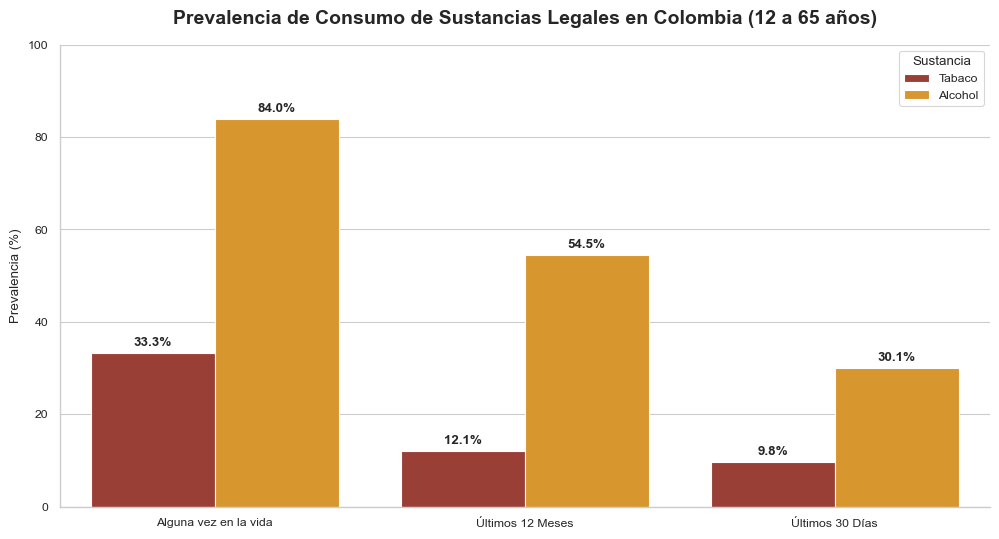

In [7]:
# Calcular prevalencias
prevalencias = {
    'Sustancia': ['Tabaco', 'Tabaco', 'Tabaco', 'Alcohol', 'Alcohol', 'Alcohol'],
    'Periodo': ['Alguna vez en la vida', 'Últimos 12 Meses', 'Últimos 30 Días', 'Alguna vez en la vida', 'Últimos 12 Meses', 'Últimos 30 Días'],
    'Tasa (%)': [
        calcular_tasa_prevalencia(df, 'tabaco_vida'),
        calcular_tasa_prevalencia(df, 'tabaco_12m'),
        calcular_tasa_prevalencia(df, 'tabaco_30d'),
        calcular_tasa_prevalencia(df, 'alcohol_vida'),
        calcular_tasa_prevalencia(df, 'alcohol_12m'),
        calcular_tasa_prevalencia(df, 'alcohol_30d')
    ]
}

df_prev = pd.DataFrame(prevalencias)

# Graficar
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_prev, x='Periodo', y='Tasa (%)', hue='Sustancia', palette=['#A93226', '#F39C12'])

# Anotaciones
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold')

plt.title('Prevalencia de Consumo de Sustancias Legales en Colombia (12 a 65 años)', pad=15, fontweight='bold', fontsize=14)
plt.ylabel('Prevalencia (%)')
plt.xlabel('')
plt.ylim(0, 100) # El eje Y va de 0 a 100%
sns.despine()

plt.savefig(FIGURES_DIR / "04_prevalencias_legales.png", dpi=300, bbox_inches='tight')
plt.show()

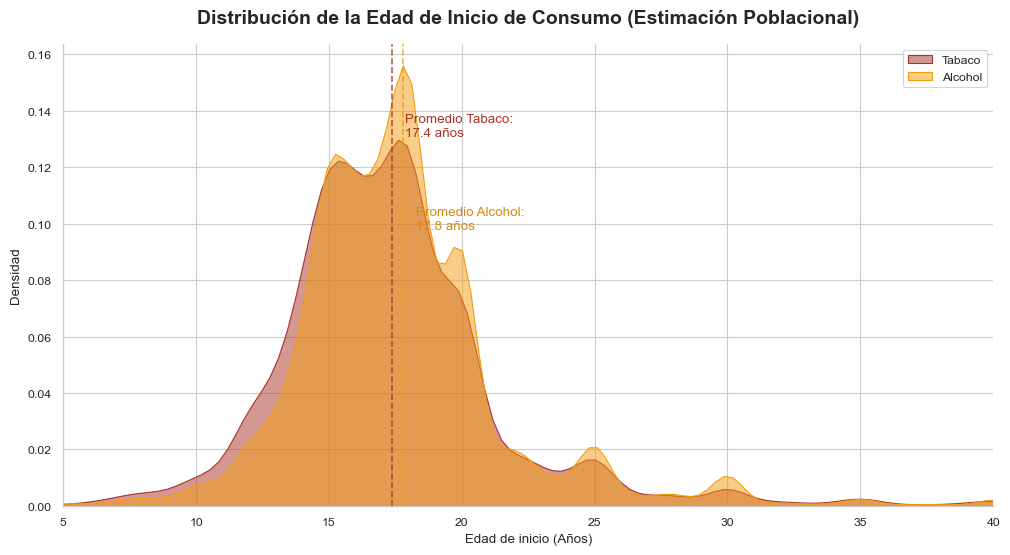

In [5]:
# Para hacer un histograma/KDE ponderado en Seaborn, usamos el parámetro 'weights'
plt.figure(figsize=(12, 6))

# Filtrar solo quienes respondieron la edad válidamente
df_edades = df[['edad_inicio_tabaco', 'edad_inicio_alcohol', 'fex_c']].dropna(how='all')

# Graficar Tabaco
sns.kdeplot(
    data=df_edades, x='edad_inicio_tabaco', weights='fex_c', 
    fill=True, color='#A93226', alpha=0.5, label='Tabaco'
)

# Graficar Alcohol
sns.kdeplot(
    data=df_edades, x='edad_inicio_alcohol', weights='fex_c', 
    fill=True, color='#F39C12', alpha=0.5, label='Alcohol'
)

plt.title('Distribución de la Edad de Inicio de Consumo (Estimación Poblacional)', pad=15, fontweight='bold', fontsize=14)
plt.xlabel('Edad de inicio (Años)')
plt.ylabel('Densidad')
plt.xlim(5, 40) # Enfocamos la vista entre los 5 y 40 años
plt.xticks(np.arange(5, 45, 5))
plt.legend()
sns.despine()

# Calcular edad promedio ponderada (Insight extra)
prom_tabaco = np.average(df['edad_inicio_tabaco'].dropna(), weights=df.loc[df['edad_inicio_tabaco'].notna(), 'fex_c'])
prom_alcohol = np.average(df['edad_inicio_alcohol'].dropna(), weights=df.loc[df['edad_inicio_alcohol'].notna(), 'fex_c'])

plt.axvline(prom_tabaco, color='#A93226', linestyle='--', alpha=0.8)
plt.axvline(prom_alcohol, color='#F39C12', linestyle='--', alpha=0.8)
plt.text(prom_tabaco+0.5, plt.ylim()[1]*0.8, f'Promedio Tabaco:\n{prom_tabaco:.1f} años', color='#A93226')
plt.text(prom_alcohol+0.5, plt.ylim()[1]*0.6, f'Promedio Alcohol:\n{prom_alcohol:.1f} años', color='#D68910')

plt.savefig(FIGURES_DIR / "05_edad_inicio_legales.png", dpi=300, bbox_inches='tight')
plt.show()

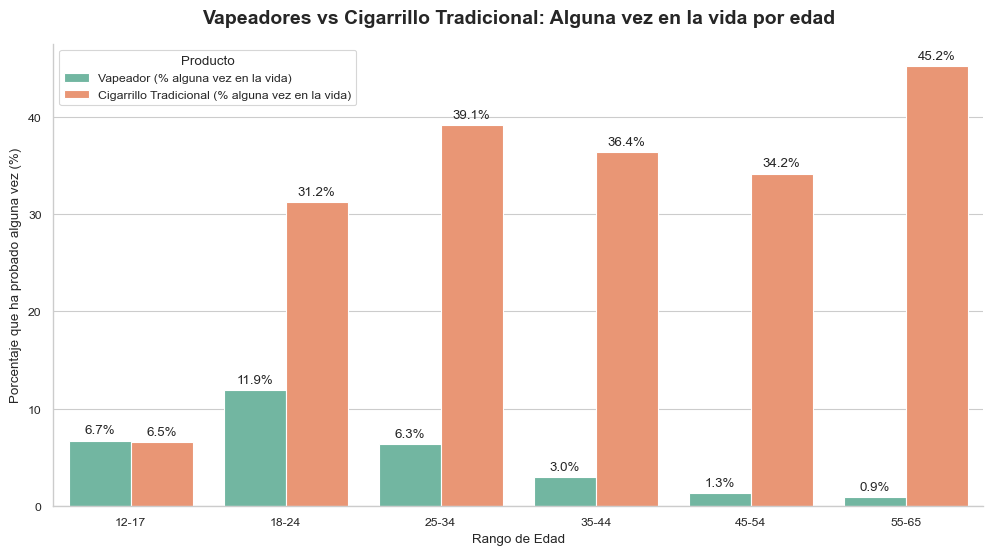

In [9]:
# Filtrar nulos en la edad
df_jovenes = df.dropna(subset=['rango_edad'])

# Tabla pivote sumando los fex_c (usamos observed=True por ser una variable categórica)
pob_total_edad = df_jovenes.groupby('rango_edad', observed=True)['fex_c'].sum()
pob_vapeador_edad = df_jovenes[df_jovenes['vapeador_vida'] == 1].groupby('rango_edad', observed=True)['fex_c'].sum()
pob_tabaco_edad = df_jovenes[df_jovenes['tabaco_vida'] == 1].groupby('rango_edad', observed=True)['fex_c'].sum()

# Construir el DataFrame
df_vape_tendencia = pd.DataFrame({
    'Rango de Edad': pob_total_edad.index,
    'Vapeador (% alguna vez en la vida)': (pob_vapeador_edad / pob_total_edad) * 100,
    'Cigarrillo Tradicional (% alguna vez en la vida)': (pob_tabaco_edad / pob_total_edad) * 100
}).reset_index(drop=True)

# ---> CORRECCIÓN: Llenar nulos (0) SOLO en las columnas numéricas calculadas <---
columnas_numericas = ['Vapeador (% alguna vez en la vida)', 'Cigarrillo Tradicional (% alguna vez en la vida)']
df_vape_tendencia[columnas_numericas] = df_vape_tendencia[columnas_numericas].fillna(0)

# Derretir el DataFrame para poder graficarlo en Seaborn (formato long)
df_melted = df_vape_tendencia.melt(id_vars='Rango de Edad', var_name='Tipo', value_name='Porcentaje (%)')

# Graficar
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melted, x='Rango de Edad', y='Porcentaje (%)', hue='Tipo', palette='Set2')

# Poner las etiquetas sobre las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Vapeadores vs Cigarrillo Tradicional: Alguna vez en la vida por edad', pad=15, fontweight='bold', fontsize=14)
plt.ylabel('Porcentaje que ha probado alguna vez (%)')
plt.xlabel('Rango de Edad')
plt.legend(title='Producto')
sns.despine()

plt.savefig(FIGURES_DIR / "06_vapeadores_vs_tabaco.png", dpi=300, bbox_inches='tight')
plt.show()

f_09: ¿Cuántos días se ha emborrachado durante los últimos 30 días?

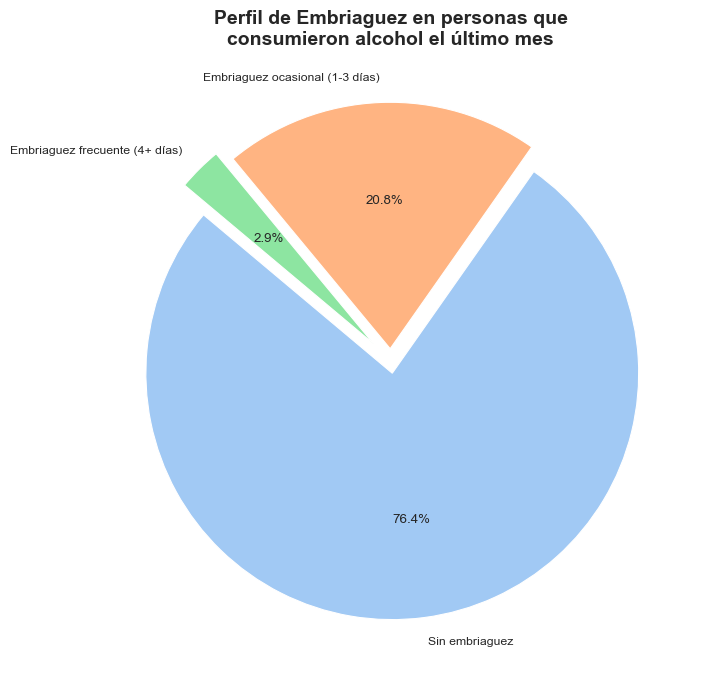

In [11]:
# f_09: ¿Cuántos días se ha emborrachado durante los últimos 30 días?
df['dias_embriaguez'] = pd.to_numeric(df['f_09'], errors='coerce')

# Ignorar valores ilógicos como 98/99 (No sabe / No responde)
df.loc[df['dias_embriaguez'] > 30, 'dias_embriaguez'] = np.nan

# 1. PRIMERO: Filtrar solo a quienes tomaron en los últimos 30 días
df_bebedores_mes = df[df['alcohol_30d'] == 1].copy()

# 2. SEGUNDO: Definir las condiciones usando el DataFrame YA FILTRADO
condiciones = [
    (df_bebedores_mes['dias_embriaguez'] == 0),
    (df_bebedores_mes['dias_embriaguez'] >= 1) & (df_bebedores_mes['dias_embriaguez'] <= 3),
    (df_bebedores_mes['dias_embriaguez'] >= 4)
]
etiquetas = ['Sin embriaguez', 'Embriaguez ocasional (1-3 días)', 'Embriaguez frecuente (4+ días)']

# 3. Asignar la nueva variable
df_bebedores_mes['perfil_embriaguez'] = np.select(condiciones, etiquetas, default='Sin dato')

# Calcular frecuencias ponderadas
resumen_embriaguez = df_bebedores_mes.groupby('perfil_embriaguez')['fex_c'].sum().reset_index()
resumen_embriaguez = resumen_embriaguez[resumen_embriaguez['perfil_embriaguez'] != 'Sin dato']

# Calcular Porcentajes
total_bebedores = resumen_embriaguez['fex_c'].sum()
resumen_embriaguez['Porcentaje'] = (resumen_embriaguez['fex_c'] / total_bebedores) * 100

# Ordenar de mayor a menor para que el gráfico quede mejor
resumen_embriaguez = resumen_embriaguez.sort_values('Porcentaje', ascending=False)

# Graficar
plt.figure(figsize=(8, 8))
plt.pie(resumen_embriaguez['Porcentaje'], labels=resumen_embriaguez['perfil_embriaguez'], 
        autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140, 
        explode=[0.05, 0.05, 0.1][:len(resumen_embriaguez)]) # Se ajusta el explode a la longitud

plt.title('Perfil de Embriaguez en personas que\nconsumieron alcohol el último mes', fontweight='bold', fontsize=14)

plt.savefig(FIGURES_DIR / "07_perfil_embriaguez.png", dpi=300, bbox_inches='tight')
plt.show()